# EGD Study

Studying the European Go Database. The data was obtained from their [documentation page](https://europeangodatabase.eu/docs/about/).

Documentation from the original file:

- `PIN`: player identification number
- `Club`: specified by internet country code and the city abbreviation
  - This is sectioned with spaces internally, which is troublesome for parsing as a CSV file, so I created an internal column called `C_Sec`. 
- `Grade`: rank professed by the player at last tournament; ranges from 20k to 1k, 1d to 7d, and from 1p to 9p
- `P&D`: suggested promotion or demotion
- `GoR`: current Go Rating of a given player
- `NT`: number of tournaments the player participated in

In [3]:
import pandas as pd

In [5]:
egd_file = '../datasets/EGD.csv'
egd = pd.read_csv(egd_file, sep='\s+', header = 0, engine = 'python')

display(egd.head())

<>:2: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:2: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/var/folders/r1/62ktytnj44749sbdwg7dwwb00000gn/T/ipykernel_42185/612691434.py:2: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  egd = pd.read_csv(egd_file, sep='\s+', header = 0, engine = 'python')


,PIN,Name,Club,C_Sec,Grade,P&D,GoR,NT,last_appearance
17301064,_,_,XX,xxx,4d,--,2393,1,T140802A
20337405,-,-,xx,xxxx,23k,--,-193,6,T231125H
20386135,-,-,CA,xxxx,5d,--,2497,1,W210802A
16749645,(undefined),Man_Hai,XX,xxxx,20k,--,34,1,T130209I
19698932,A,Connie,UK,xxxx,30k,--,-814,1,T210308A


In [6]:
display(egd.describe())

,GoR
count,56029.000000
mean,912.231202
std,826.533358
min,-900.000000
25%,142.000000
50%,814.000000
75%,1600.000000
max,2949.000000


In [16]:
print(f'Total Number of Players: {egd.shape[0]}')

Total Number of Players: 56029


In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

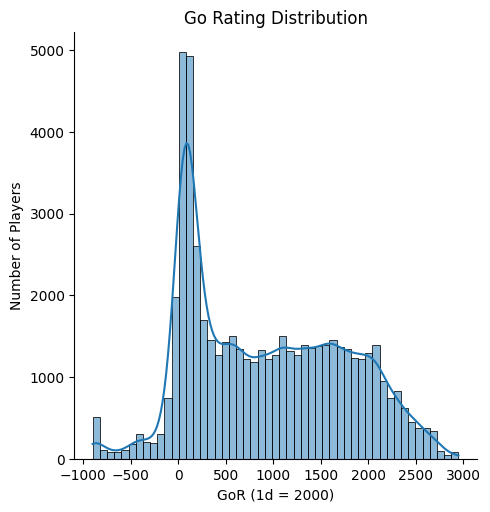

In [ ]:
sns.displot(data=egd, x="GoR", kde=True)
plt.xlabel('Go Rating (1 dan = 2000)')
plt.ylabel('Number of Players')
plt.title('Go Rating Distribution')
plt.show()

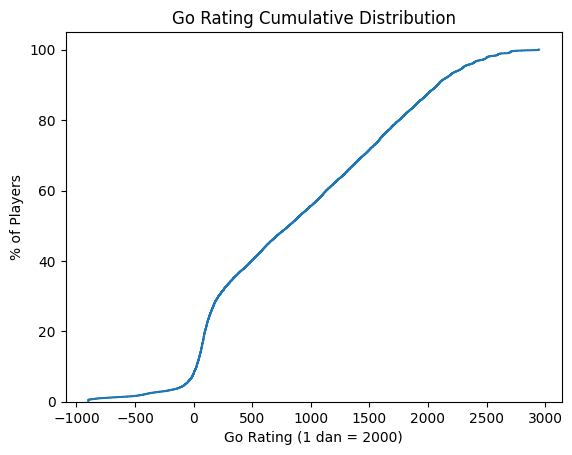

In [15]:
sns.ecdfplot(data=egd, x="GoR", stat='percent')
plt.xlabel('Go Rating (1 dan = 2000)')
plt.ylabel('% of Players')
plt.title('Go Rating Cumulative Distribution')
plt.show()

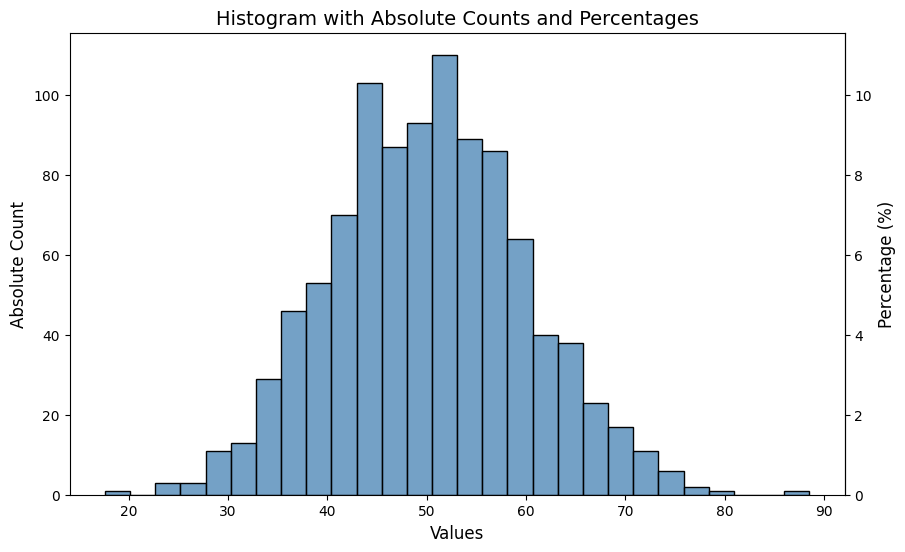

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Generate sample data
np.random.seed(42)
data = pd.DataFrame({'values': np.random.randn(1000) * 10 + 50})

# 2. Create the primary histogram (absolute counts)
fig, ax1 = plt.subplots(figsize=(10, 6))
sns.histplot(data=data, x='values', ax=ax1, color='steelblue')

# 3. Define the conversion functions for the secondary axis
n_obs = len(data)
def func_percent(x):
    return (x / n_obs) * 100

def func_count(x):
    return (x * n_obs) / 100

# 4. Attach the secondary y-axis
ax2 = ax1.secondary_yaxis('right', functions=(func_percent, func_count))

# 5. Add labels and formatting
ax1.set_xlabel('Values', fontsize=12)
ax1.set_ylabel('Absolute Count', fontsize=12)
ax2.set_ylabel('Percentage (%)', fontsize=12)
plt.title('Histogram with Absolute Counts and Percentages', fontsize=14)

plt.show()
